<a href="https://colab.research.google.com/github/filipef-castro/curso_ads_atividades_avaliativas/blob/main/Curso_ADS_L%C3%B3gica_de_Programa%C3%A7%C3%A3o_Atividade_Avaliativa_Unidade_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PRIMEIRAS LINHAS:
   id_venda  data_venda    produto    categoria  valor_venda
0         1  2023-01-01  Produto A  Eletrônicos       1500.0
1         2  2023-01-05  Produto B       Roupas        350.0
2         3  2023-02-10  Produto C  Eletrônicos       1200.0
3         4  2023-03-15  Produto D       Livros        200.0
4         5  2023-03-20  Produto E  Eletrônicos        800.0
ULTIMAS LINHAS:
    id_venda  data_venda    produto    categoria  valor_venda
9         10  2023-08-25  Produto J  Eletrônicos        700.0
10        11  2023-09-30  Produto K       Livros        300.0
11        12  2023-10-05  Produto L       Roupas        450.0
12        13  2023-11-15  Produto M  Eletrônicos        900.0
13        14  2023-12-20  Produto N       Livros        250.0

INFORMAÇÕES DO DATAFRAME:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venda  

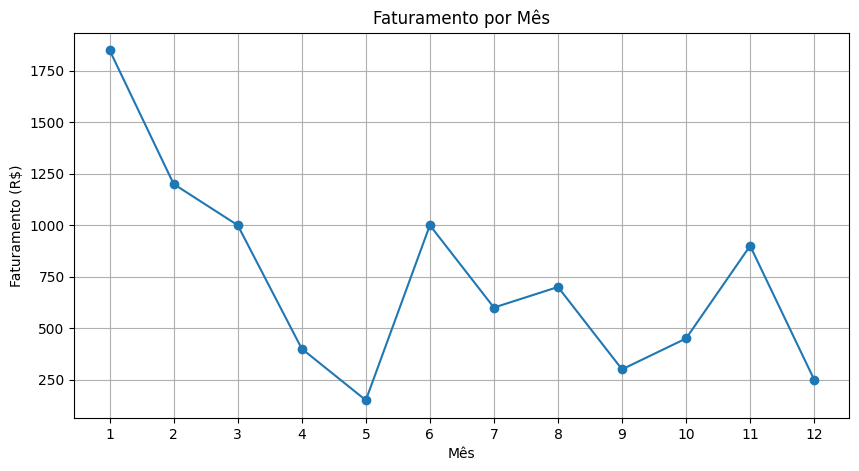

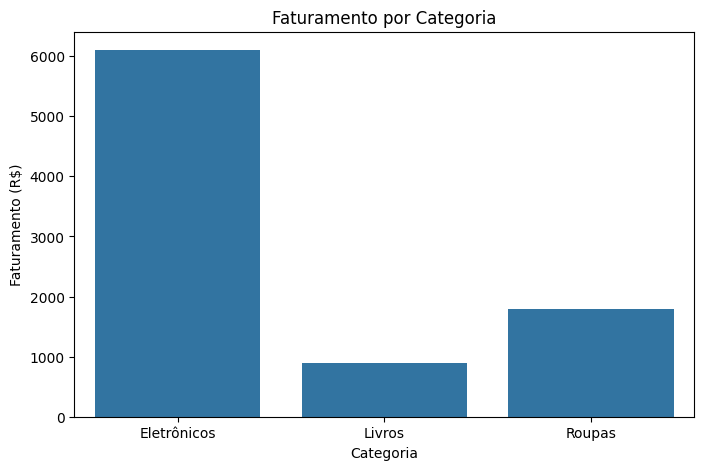

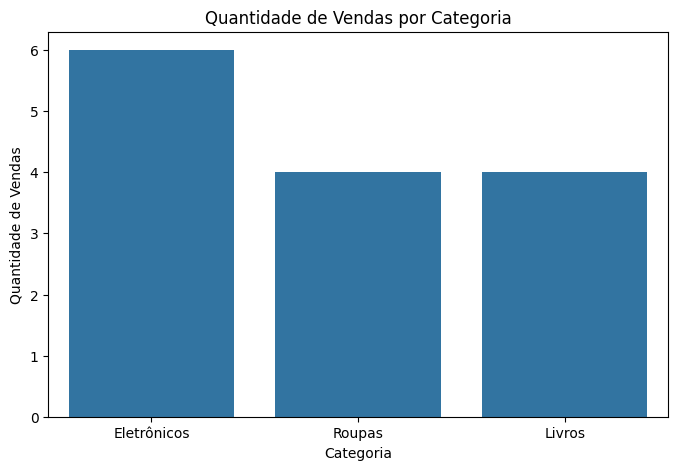

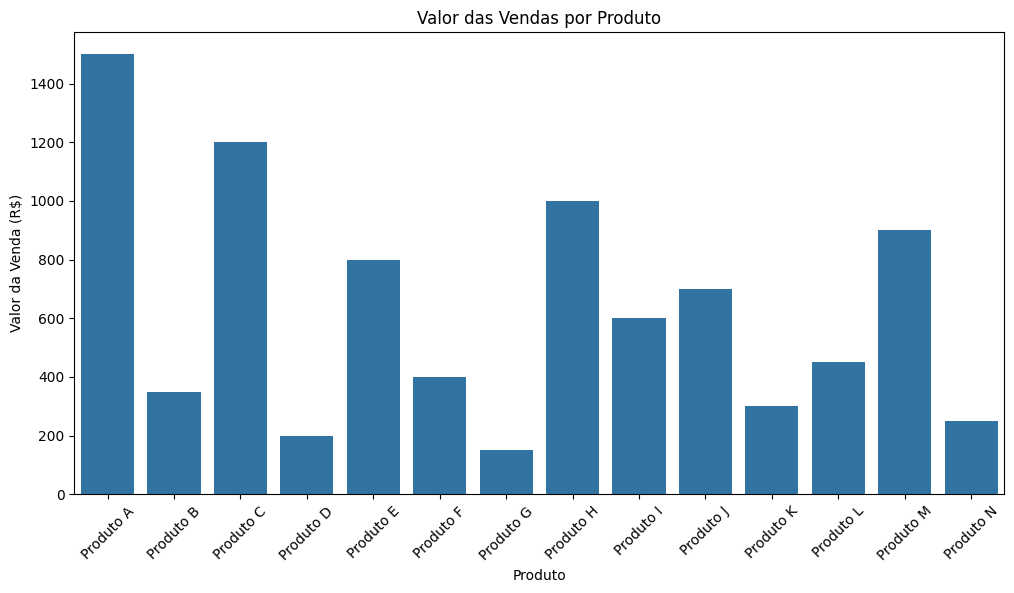

In [ ]:
#IMPORTAÇÃO DAS BIBLIOTECAS QUE SERÃO UTILIZADAS NO NOSSO CÓDIGO
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#CRIANDO CONEXÃO COM O SQL E CRIANDO O CURSOS
conexao = sqlite3.connect('dados_vendas.db')
cursor = conexao.cursor()

#CRIAÇÃO DA TABELA
cursor.execute('''
CREATE TABLE IF NOT EXISTS vendas1 (
    id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
    data_venda DATE,
    produto TEXT,
    categoria TEXT,
    valor_venda REAL
)
''')

#INSERINDO DADOS NA TABELA
cursor.execute('''
INSERT INTO vendas1 (data_venda, produto, categoria, valor_venda) VALUES
('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
('2023-01-05', 'Produto B', 'Roupas', 350.00),
('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
('2023-03-15', 'Produto D', 'Livros', 200.00),
('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
('2023-04-02', 'Produto F', 'Roupas', 400.00),
('2023-05-05', 'Produto G', 'Livros', 150.00),
('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
('2023-07-20', 'Produto I', 'Roupas', 600.00),
('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
('2023-09-30', 'Produto K', 'Livros', 300.00),
('2023-10-05', 'Produto L', 'Roupas', 450.00),
('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
('2023-12-20', 'Produto N', 'Livros', 250.00);
''')

#INSERINDO CONFIRMAÇÃO DA MUDANÇA
conexao.commit()

#CARREGANDO OS DADOS NO PANDA
df_vendas = pd.read_sql_query(
    "SELECT * FROM vendas1",
    conexao
)

#EXPLORAÇÃO DOS DADOS
print("PRIMEIRAS LINHAS:")
print(df_vendas.head())

print("ULTIMAS LINHAS:")
print(df_vendas.tail())

print("\nINFORMAÇÕES DO DATAFRAME:")
df_vendas.info()

print("\nESTATÍSTICAS:")
print(df_vendas.describe())

#PREPARAÇÃO DOS DADOS

# Converte a coluna de texto para o formato de data.
df_vendas['data_venda'] = pd.to_datetime(
    df_vendas['data_venda']
)

# Cria uma coluna contendo o número do mês.
df_vendas['mes'] = df_vendas['data_venda'].dt.month


#ANÁLISE GERAL
faturamento_total = df_vendas['valor_venda'].sum()

media_vendas = df_vendas['valor_venda'].mean()

quantidade_vendas = df_vendas['id_venda'].count()

maior_venda = df_vendas['valor_venda'].max()

menor_venda = df_vendas['valor_venda'].min()

print(f"Faturamento total: R$ {faturamento_total:,.2f}")
print(f"Média das vendas: R$ {media_vendas:,.2f}")
print(f"Quantidade de vendas: {quantidade_vendas}")
print(f"Maior venda: R$ {maior_venda:,.2f}")
print(f"Menor venda: R$ {menor_venda:,.2f}")


#ANÁLISE POR CATEGORIA
vendas_categoria = df_vendas.groupby(
    'categoria'
)['valor_venda'].sum()

quantidade_categoria = df_vendas[
    'categoria'
].value_counts()


print("\n========== FATURAMENTO POR CATEGORIA ==========")
print(vendas_categoria)

print("\n========== QUANTIDADE DE VENDAS POR CATEGORIA ==========")
print(quantidade_categoria)


# ANÁLISE POR MÊS
vendas_mes = df_vendas.groupby(
    'mes'
)['valor_venda'].sum()

print("\n========== FATURAMENTO POR MÊS ==========")
print(vendas_mes)


#PARTICIPAÇÃO DAS CATEGORIAS
participacao_categoria = (
    vendas_categoria / faturamento_total
) * 100

print("\n========== PARTICIPAÇÃO NO FATURAMENTO ==========")
print(participacao_categoria)


#GRÁFICO DE FATURAMENTO POR MÊS
plt.figure(figsize=(10, 5))

plt.plot(
    vendas_mes.index,
    vendas_mes.values,
    marker='o'
)

plt.title('Faturamento por Mês')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')

plt.xticks(range(1, 13))

plt.grid(True)

plt.show()


#GRÁFICO DE FATURAMENTO POR CATEGORIA


plt.figure(figsize=(8, 5))

sns.barplot(
    x=vendas_categoria.index,
    y=vendas_categoria.values
)

plt.title('Faturamento por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento (R$)')

plt.show()


#GRÁFICO DE QUANTIDADE DE VENDAS
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_vendas,
    x='categoria'
)

plt.title('Quantidade de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Quantidade de Vendas')

plt.show()



#GRÁFICO DE VENDAS POR PRODUTO
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_vendas,
    x='produto',
    y='valor_venda'
)

plt.title('Valor das Vendas por Produto')
plt.xlabel('Produto')
plt.ylabel('Valor da Venda (R$)')

plt.xticks(rotation=45)

plt.show()


#ENCERRAMENTO DA CONEXÃO
conexao.close()